# 의료비 예측 MLP 회귀모델

### 실습순서 
- kaggle 에서 데이터(csv) 다운로드
    
1. 수치형 / 범주형 데이터 확인
2. train / valid / test 데이터 분리
3. 수치형 정규화 / 범주형 One-Hot Encoding
4. target 값 로그 변환 및 표준화
5. Pytorch Tensor 형태로 데이터 변환
6. Dataset / Loader 로 미니배치 학습준비
7. 다층 퍼셉트론(MLP) 회귀 모델 설계
8. BatchNorm, Dropout, SiLU 활성화 함수 적용
9. HuberLoss 손실함수, AdamW 최적화 함수, Scheduler, Gradient Clipping, EarlyStopping 적용
10. 학습 및 검증
11. 지표확인/ 시각화
12. 테스트 데이터로 최종확인
13. 임의의 데이터로 테스트

1. 라이브러리 import 

In [1]:
import os 
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

import torch
import torch.nn as nn                                   # 신경망 구성 및 손실함수
from torch.utils.data import TensorDataset, DataLoader  # Tensor 데이터셋 / 미니배치 로더

import kagglehub
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split, KFold   # 데이터 분리 / K-Fold 검증
from sklearn.pipeline import Pipeline       # 전처리 과정 통합
from sklearn.impute import SimpleImputer    # 결측치 처리
from sklearn.preprocessing import StandardScaler, OneHotEncoder    # 표준화
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer


plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False

c:\Users\MoonSungHo\skn34-st\study\DL\DL_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 시드값 고정, CPU/GPU 사용 장치 설정

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('사용장치 : ', device)

사용장치 :  cpu


# 2. 데이터 다운로드

In [3]:
# Download latest version
data_path = kagglehub.dataset_download("mirichoi0218/insurance", path= 'insurance.csv')

df = pd.read_csv(data_path)

df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
print(df.shape)

print(df.info())

(1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB
None


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
# 범주형 컬럼
categorical_cols = ['sex', 'smoker', 'region']

for col in categorical_cols:
    print(df[col].value_counts())   # 범주형 값 갯수

sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


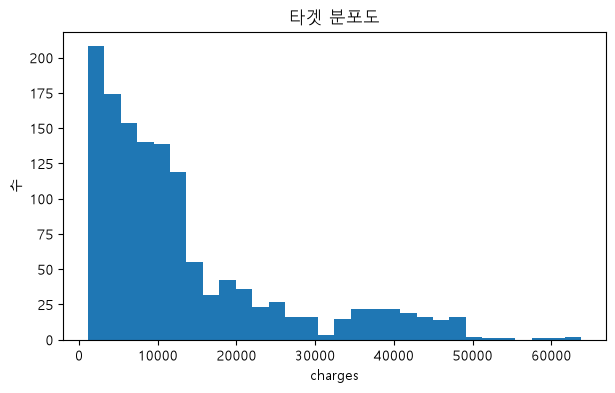

In [7]:
# target 컬럼 분포도

plt.figure(figsize=(7,4))
plt.hist(df['charges'], bins=30)
plt.title('타겟 분포도')
plt.xlabel('charges')
plt.ylabel('수')
plt.show()

타겟 데이터는 적은 치료비가 많은 상태

<Figure size 700x400 with 0 Axes>

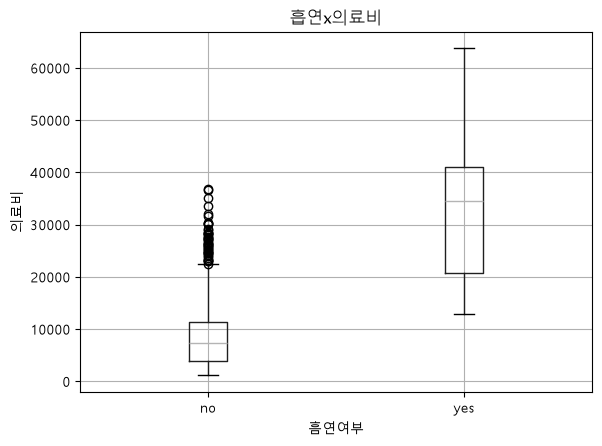

In [8]:
# 흡연 여부에 따른 의료비 차이

plt.figure(figsize=(7,4))
df.boxplot(column='charges', by= 'smoker')      # 흡연여부별 의료비 boxplot
plt.title('흡연x의료비')
plt.suptitle('')            # 기존 자동생성 상위제목 제거
plt.xlabel('흠연여부')
plt.ylabel('의료비')
plt.show()

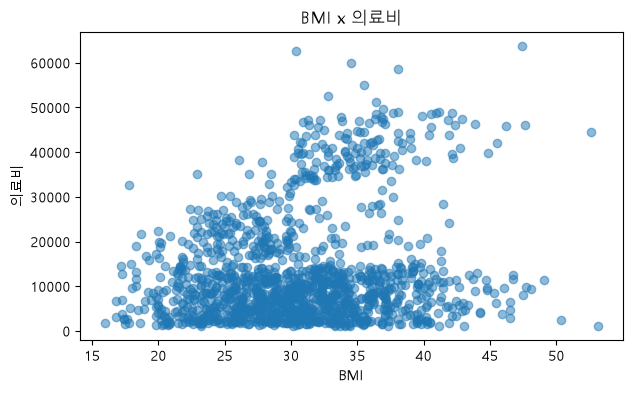

In [9]:
# BMI 와 의료비 관계

plt.figure(figsize=(7,4))
plt.scatter(df['bmi'], df['charges'], alpha= 0.5)      # BMI와 의료비 관계 산점도
plt.title('BMI x 의료비')
plt.xlabel('BMI')
plt.ylabel('의료비')
plt.show()

## 3. 입력데이터와 정답데이터 분리

In [10]:
X = df.drop(columns= 'charges')
y = df['charges']

print(X.shape, y.shape)

(1338, 6) (1338,)


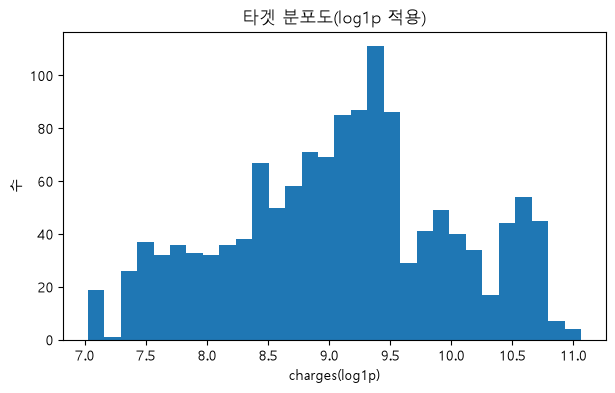

In [11]:
# target 컬럼이 왼쪽으로 치우친 형태이므로 로그 변환 적용
y_log = np.log1p(y)

plt.figure(figsize=(7,4))
plt.hist(y_log, bins=30)
plt.title('타겟 분포도(log1p 적용)')
plt.xlabel('charges(log1p)')
plt.ylabel('수')
plt.show()

log 변환 적용 해주니 정규분포와 가까워진 형태로 변환됨

## 4. Train/ Valid / Test 데이터 분리

컬럼 설명



In [12]:
# test데이터를 8:2 비율로 나눈다 (전역 시드값 설정, y비율 유지)

X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y_log,
    test_size= 0.2,     # 80:20
    random_state= SEED,
    # stratify= y        회귀라서 안써도됌
)

# 남은 80% 중 8:2 비율로 train / valid 데이터를 나눈다.
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid,
    test_size = 0.2,      
    random_state = SEED
)   


print(f'X_train : {X_train.shape}, X_test : {X_test.shape}, X_valid : {X_valid.shape}, ')
print(f'y_train : {y_train.shape}, y_test : {y_test.shape}, y_valid : {y_valid.shape}, ')

X_train : (856, 6), X_test : (268, 6), X_valid : (214, 6), 
y_train : (856,), y_test : (268,), y_valid : (214,), 


## 5. 전처리 PipeLine 구성
- 수치형 : 정규화
- 범주형 : One - Hot 인코딩 

In [13]:
# 범주형, 수치형 컬럼 구분

categorical_features = ['sex', 'smoker', 'region']
numeric_features = ['age', 'bmi', 'children']

onehot_encoder = OneHotEncoder(
    handle_unknown= 'ignore',   # 학습시 없던 범주가 입력되어도 오류 없이 무시
    sparse_output= False        # True : 희소행렬, False : 일반 Numpy 배열로 반환
    
    )

# 범주형 전처리
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),   # 결측값 최빈값 대체
    ('onehot', onehot_encoder)                              # 원핫인코딩
])

# 수치형 전처리 
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # 결측값 중앙값 대체
    ('scaler', StandardScaler())                    # 표준화
])

# 컬럼별 전처리 통합
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),                # 수치형 컬럼에는 수치형 전처리
    ('category', categorical_pipeline, categorical_features)    # 범주형 컬럼에는 범주형 전처리
])

In [14]:
# preprocessor 전처리 도구로 학습 및 변환

X_train_scaled = preprocessor.fit_transform(X_train)
X_valid_scaled = preprocessor.transform(X_valid)
X_test_scaled = preprocessor.transform(X_test)

print(X_train_scaled.shape,
X_valid_scaled.shape, 
X_test_scaled.shape)

(856, 11) (214, 11) (268, 11)


In [15]:
# target 데이터 표준화 : 타겟 데이터의 범위가 클때 학습이 불안정해질 수 있어 표준화 작업 진행

y_mean = y_train.mean()     # train target 의 평균
y_std = y_train.std()       # train target 의 표준편차

# train 기준 평균과 표준편차로 모든 target 데이터 표준화
y_train_scaled = (y_train - y_mean) / y_std
y_valid_scaled = (y_valid - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

print(f'target mean : {y_mean}, target std : {y_std}')  # 표준화에 사용한 평균, 표준편차

target mean : 9.104843701853595, target std : 0.9082830243269455


## 6. Pytorch Tensor 형태로 변환

In [16]:
# 입력 데이터 tensor로 변환
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_valid_tensor = torch.FloatTensor(X_valid_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

# 정답 데이터 tensor로 변환
y_train_tensor = torch.FloatTensor(y_train_scaled.to_numpy()).reshape(-1, 1)
y_valid_tensor = torch.FloatTensor(y_valid_scaled.to_numpy()).reshape(-1, 1)
y_test_tensor = torch.FloatTensor(y_test_scaled.to_numpy()).reshape(-1, 1)

print(X_train_tensor.shape, X_valid_tensor.shape, X_test_tensor.shape)
print(y_train_tensor.shape, y_valid_tensor.shape, y_test_tensor.shape)

torch.Size([856, 11]) torch.Size([214, 11]) torch.Size([268, 11])
torch.Size([856, 1]) torch.Size([214, 1]) torch.Size([268, 1])


C:\Users\MoonSungHo\AppData\Local\Temp\ipykernel_24352\1250866229.py:7: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train_tensor = torch.FloatTensor(y_train_scaled.to_numpy()).reshape(-1, 1)


## 7. TensorDataSet/ DataLoader 로 미니배치 데이터 준비

In [17]:
# 입력 Tensor와 정답 Tensor를 하나의 데이터셋으로 묶음
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 32


# 학습/검증/테스트 DataLoader 를 batch_size 로 나눠 생성()
train_loader = DataLoader(train_dataset, batch_size= BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size= BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size= BATCH_SIZE, shuffle=False)

print(len(train_loader),len(valid_loader),len(test_loader))

27 7 9


## 8. 다층 퍼셉트론 회귀 모델 설계

In [18]:
class RegressionMLP(nn.Module):
    
    def __init__(self,input_dim , hidden_dims = [128, 64, 32], dropout= 0.2):
        super().__init__()      #nn.Module 초기화
        
        layers = []             # 모델 레이어를 순서대로 저장할 리스트
        prev_dim = input_dim    # 현재층
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))   # 배치 정규화(학습 안정성)
            layers.append(nn.SiLU())                    # 비선형 활성화 함수
            layers.append(nn.Dropout(dropout))          # 랜덤하게 20% 노드를 끔(과적합 완화)
            prev_dim = hidden_dim                       
        
        
        layers.append(nn.Linear(prev_dim, 1))   # 회귀 : 예측값 1개
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        
        return self.network(x)

In [19]:
input_dim = X_train_tensor.size(-1)     # 입력 특성 갯수

model = RegressionMLP(input_dim= input_dim).to(device)  
model

RegressionMLP(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

## 9. 손실함수, Optimizer, Scheduler 설정

In [20]:
# HuberLoss 손실함수 : 작은 오차는 MSE, 큰 오차는 MAE 방식으로 작동한다.
criterion = nn.HuberLoss(delta= 1.0)

# AdamW 최적화 함수: Adam + weight_decay(가중치 감쇠)로 안정적인 학습
optimizer = torch.optim.AdamW(
    model.parameters(),     # 학습할 모델 파라미터
    lr = 0.001,             # 학습률
    weight_decay= 0.01      # 가중치 감쇠율(과적합 완화)
)

# val_loss 기준으로 일정 epoch 동안 개선 없을시 학습률 감소
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,          # 조절할 최적화 함수
    mode = 'min',       # validation_loss 는 최소화 해야하므로 min
    factor = 0.5,       # 감소 비율
    patience = 5        # 5 epoch동안 개선 없으면 감소
)

## 10. EarlyStopping

In [21]:
# EarlyStopping : 일정 epoch동안 성능이 좋아지지 않으면 학습을 멈추는 도구
class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.0):
        self.patience = patience    # 개선이 없을떄 기다릴 epoch 수
        self.min_delta = min_delta  # 개선으로 인정할 최소 손실 감소량
        self.best_loss = np.inf     # 현재까지 가장 낮은 valid loss
        self.counter = 0            # 개선이 없던 epoch 수
        self.best_state = None      # 가장 성능이 좋은 모델의 가중치
        self.should_stop = False    # 학습 중단 여부 플래그

    def step(self, valid_loss, model):
        # 최소 손실 갱신시
        if valid_loss < self.best_loss - self.min_delta:
            self.best_loss = valid_loss
            self.counter = 0

            # 가장 좋은 모델의 가중치 저장
            self.best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
        else:
            self.counter += 1

            # patience 동안 개선이 없을시
            if self.counter >= self.patience:
                self.should_stop = True # 학습 중단 신호

## 11. 학습 및 검증
- 학습
1. 예측값 계산
2. 손실 계산
3. 기존 기울기 초기화
4. 오차역전파 : 기울기 계산
5. Gridient Clipping : 기울기 폭주 방지
6. 가중치 업데이트

In [22]:
def train_one_epoch(model, data_loader, criterion, optimizer, device, max_grad_norm = 1.0):
    model.train()
    total_loss = 0

    # 미니배치 32개 단위로 반복
    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)    # 입력 데이터를 CPU/GPU로 이동
        y_batch = y_batch.to(device)    # 정답 데이터를 CPU/GPU로 이동

        optimizer.zero_grad()           # 이전 step 기울기 초기화
        logits = model(X_batch)         # 예측값 계산
        loss = criterion(logits, y_batch)   # 손실 계산

        loss.backward()                 # 기울기 계산
        nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)     # Gradient Clipping()
        optimizer.step()                # 가중치 업데이트

        total_loss += loss.item() * len(X_batch)    # 배치 손실을 데이터 수만큼 누적

    return total_loss / len(data_loader.dataset)    # 데이터 1개당 평균 손실 반환



def evalute_loss(model, data_loader, criterion, device):
    model.eval()    # 평가 모드로 설정
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device) # 입력 데이터 장치로 이동
            y_batch = y_batch.to(device) # 정답 데이터 장치로 이동

            output = model(X_batch)             # 예측값 계산
            loss = criterion(output, y_batch)   # 손실값 계산
            

            total_loss += loss.item() * len(X_batch)    # 배치 손실을 데이터 수만큼 누적

    return total_loss / len(data_loader.dataset)    # 데이터 1개당 평균 손실 반환

## 12. 모델 학습

In [23]:
EPOCHS = 200    # 최대 학습 횟수

early_stopping = EarlyStopping(patience=20, min_delta=0.0001)   # 20번 동안 최소 개선 기준 0.0001 이상 개선되지 않으면 학습 중단

history = {
    'train_loss' : [],
    'valid_loss' : [],
    'lr' : []
}

for epoch in tqdm( range(1, EPOCHS + 1), desc='Training'):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss = evalute_loss(model, valid_loader, criterion, device)

    scheduler.step(valid_loss)  # valid_loss 기준으로 학습률 조정

    current_lr = optimizer.param_groups[0]['lr']    # 현재 학습률 확인

    history['train_loss'].append(train_loss)
    history['valid_loss'].append(valid_loss)
    history['lr'].append(current_lr)

    early_stopping.step(valid_loss, model)  # Valid_loss 기준으로 EarlyStopping 상태 업데이트

    # 20번 동안 개선 없을시 Flag True가 되면
    if early_stopping.should_stop:
        print(f'{epoch} Epoch에서 Early Stopping 작동하여 학습 중지!')
        break

# 가장 성능이 좋은 모델의 가중치 복원
if early_stopping.best_state is not None:
    model.load_state_dict(early_stopping.best_state)

history_df = pd.DataFrame(history)
history_df


Training:  28%|██▊       | 55/200 [00:31<01:22,  1.76it/s]

56 Epoch에서 Early Stopping 작동하여 학습 중지!


,train_loss,valid_loss,lr
0,0.269023,0.187444,0.001000
1,0.140154,0.110575,0.001000
2,0.125584,0.105873,0.001000
3,0.117660,0.110985,0.001000
4,0.120645,0.107557,0.001000
5,0.106034,0.108698,0.001000
6,0.104141,0.102629,0.001000
7,0.097457,0.104880,0.001000
8,0.103720,0.105694,0.001000
9,0.105965,0.106024,0.001000


## 13. 지표확인

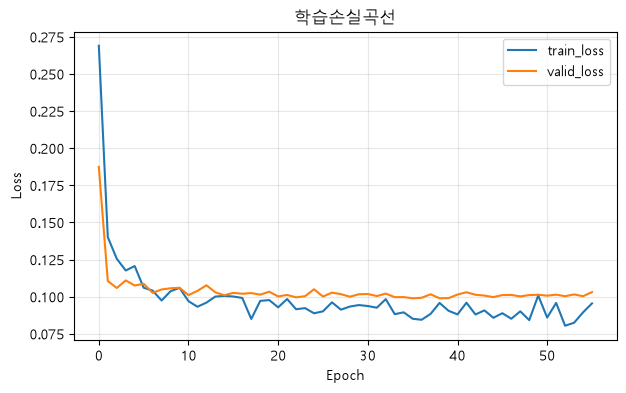

In [24]:
# 학습/ 검증 손실곡선
plt.figure(figsize=(7, 4))
plt.plot(history['train_loss'], label='train_loss') 
plt.plot(history['valid_loss'], label='valid_loss') 
plt.title('학습손실곡선')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()    # 범례
plt.grid(alpha=0.3)
plt.show()

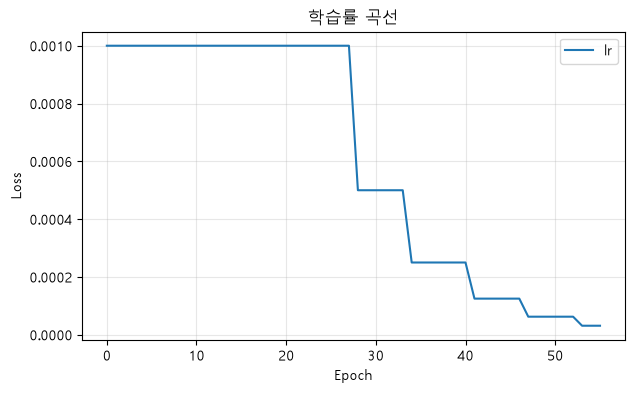

In [25]:
# 학습률 곡선 시각화
plt.figure(figsize=(7, 4))
plt.plot(history['lr'], label='lr') 
plt.title('학습률 곡선')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()    # 범례
plt.grid(alpha=0.3)
plt.show()

## 14. 테스트 데이터로 최종 평가

In [26]:
# 타겟값을 역변환 시켜주는 함수
def inverse_target(y_scaled):
    y_log_restored = y_scaled * y_std + y_mean   # 정규화 복원작업
    
    return np.expm1(y_log_restored)     # log1p 역변환(복원)


# 실제값과 모델 예측확률을 반환해주는 함수
def predict_loader(model, data_loader, device):
    model.eval()        # 평가 모드
    preds = []     # 예측 모드
    target_list = []    # 정답

    # 예측시 기울기 계산 비활성화
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)    # 입력 데이터만 장치로 이동

            output = model(X_batch)         # 모델 출력값
            

            preds.append(output.cpu().numpy())  # 예측값을 CPU Numpy로 변환해 저장
            target_list.append(y_batch.numpy())     

        preds = np.vstack(preds).ravel()   # 예측값을 1차원으로 변환
        y_true = np.vstack(target_list).ravel() # 정답을 1차원으로 변환

    return preds, y_true

In [29]:
test_pred_scaled, test_true_scaled = predict_loader(model, test_loader, device)

test_pred = inverse_target(test_pred_scaled)
test_true = inverse_target(test_true_scaled)

mae = mean_absolute_error(test_true, test_pred)
rmse = np.sqrt(mean_squared_error(test_true, test_pred))
r2 = r2_score(test_true, test_pred)

print(f"MAE : {mae:.4f}")
print(f"MSE : {rmse:.4f}")
print(f"R2 : {r2:.4f}")


MAE : 2184.6027
MSE : 4485.4998
R2 : 0.8704
